# ACES simulation & the agentic-commerce research questions

**The master notebook of the reorganised `conveyer` project.** It (1) recaps the
results established by notebooks 01–03, (2) integrates the
[ACES agentic-commerce simulator](https://github.com/mycustomai/ACES)
([arXiv:2508.02630](https://arxiv.org/abs/2508.02630)) to study prompt→choice
dynamics and to augment the conversation DB, and (3) states a **hypothesis and a
working prototype for each research question** (Q1–Q8).

| Notebook | What it established |
|---|---|
| `01_text_clustering_pipeline` | conversation segments (5 clustering methods + BERTopic), per-segment recommendation behaviour |
| `02_similarweb_star_schema` | the SimilarWeb star schema: 39,541 turns · 4,622 sessions · 3,319 users; 7-stage funnel scores per turn; 34 topics; entity + concept tables and their true join keys |
| `03_message_enrichment` | transformer classifiers (intent, sentiment), brand-pair flags (endorsed / unsolicited / substitution), token accounting |
| **04 (this one)** | ACES integration · prompt-perturbation dynamics · DB augmentation · Q1–Q8 prototypes |

Everything below runs on the real data when `data/` is populated, and on the
package's synthetic English conversations otherwise — so the *methods* are
executable and reviewable before the data lands. All estimators are validated
the same way: **simulate from known ground truth → recover it**.

## 1 · Setup & data

`conveyer` v0.2 modules used here: `aces` (simulator), `augment` (DB expansion),
`funnel` (journey-stage HMM), `graphs` (interaction network), `attribution`
(Bayesian conversion / MRP / MMM / MNL / Shapley).

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "conveyer").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from conveyer import (PipelineConfig, aces, analysis, attribution, augment,
                      funnel, graphs, ingest)

SEED = 7
rng = np.random.default_rng(SEED)
OUT = ROOT / "outputs"
(OUT / "aces").mkdir(parents=True, exist_ok=True)

# categorical palette (validated for CVD + contrast; see dataviz notes)
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.axisbelow": True,
})

cfg = PipelineConfig(data_path=str(ROOT / "data" / "conversations.parquet"),
                     synthetic_n=1200, first_turn_only=False)
df = ingest.ingest(cfg)
SOURCE = df.attrs.get("source", "?")
df = analysis.add_brand_features(df)
df = analysis.add_intent(df, cfg)
df = funnel.add_stage(df)
if "user_id" not in df.columns:  # synthetic fallback has no user ids
    df["user_id"] = "u" + (pd.factorize(df["session_id"])[0] // 2).astype(str)

print("source:", SOURCE)
print(f"{len(df):,} turns · {df['session_id'].nunique():,} sessions · "
      f"{df['user_id'].nunique():,} users")

source: SYNTHETIC (1200 rows; /home/user/conveyer/data/conversations.parquet not found)
1,200 turns · 400 sessions · 200 users


In [2]:
# SimilarWeb star schema (profiled in notebook 02) — used when present
SW_DIR = ROOT / "data" / "similarweb_transformed_data"
star = ({p.stem: pd.read_parquet(p) for p in sorted(SW_DIR.glob("*.parquet"))}
        if SW_DIR.exists() else {})
print("star-schema tables:", list(star) if star else
      "not present -> sections below fall back to the conversation log")

star-schema tables: not present -> sections below fall back to the conversation log


## 2 · Recap — where the exploration stands (reorganised)

The headline facts from notebooks 01–03, recomputed live on the loaded data so
this notebook is self-contained:

- **Intent mix** (rule/anchor classifier, upgradeable to the transformer version
  of notebook 03): recommendation-seeking turns are the commercial surface.
- **Funnel stage** (keyword classifier aligned with `dim_ai_funnel`): most turns
  sit in Discovery/Evaluation — mid-funnel is where the LLM operates.
- **Brand amplification**: the LLM names far more brands than users ask about;
  `unsolicited` mentions are *recommendation events* and concentrate on a short
  head of brands.

In [3]:
amp = analysis.brand_amplification(df)
top_reco = analysis.top_recommendations(df, k=10)

recap = pd.Series({
    "turns": len(df),
    "sessions": df["session_id"].nunique(),
    "reco_rate (turn has unsolicited brand)": round(df["is_recommendation"].mean(), 3),
    "brands per answer (mean)": round(df["n_brands_answer"].mean(), 2),
    "distinct brands in answers": int(amp["a_count"].gt(0).sum()),
}, name="value")
display(recap.to_frame())
print("Top LLM-introduced (unsolicited) brands on recommendation-seeking turns:")
display(top_reco.head(8))

,value
turns,1200.000
sessions,400.000
reco_rate (turn has unsolicited brand),0.935
brands per answer (mean),2.360
distinct brands in answers,18.000


Top LLM-introduced (unsolicited) brands on recommendation-seeking turns:


,brand,times_recommended
0,the ordinary,107
1,la roche-posay,102
2,cerave,70
3,bioderma,70
4,cetaphil,64
5,good molecules,42
6,isdin,40
7,skinceuticals,36


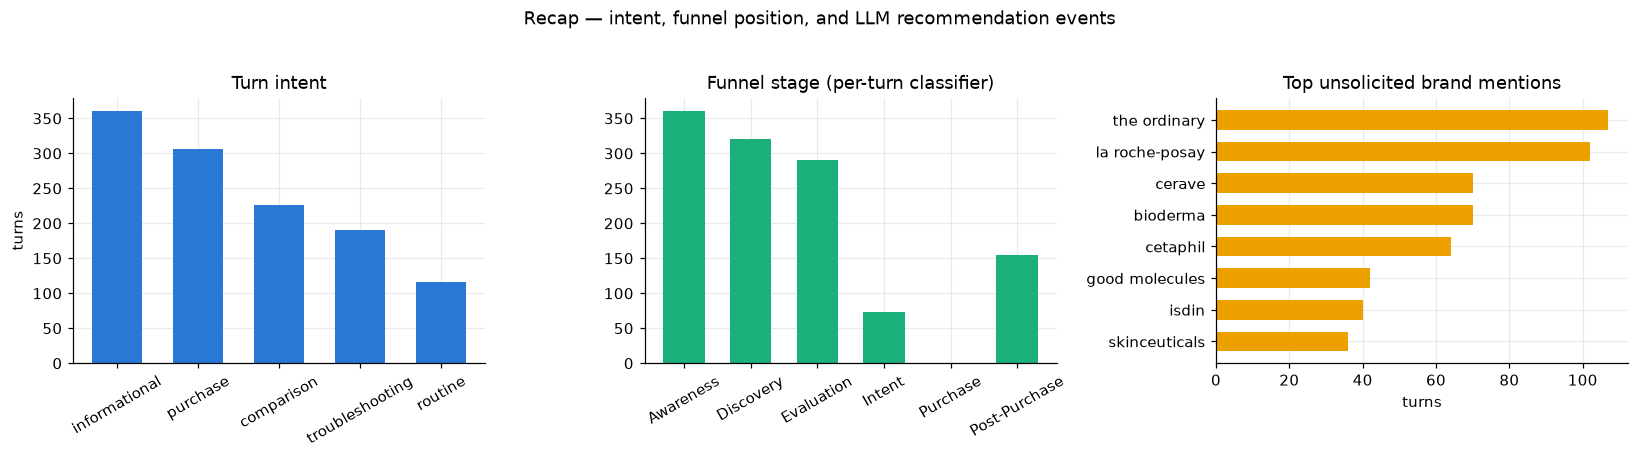

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

vc = df["intent"].value_counts()
ax[0].bar(vc.index, vc.values, color=C[0], width=0.62)
ax[0].set(title="Turn intent", ylabel="turns")
ax[0].tick_params(axis="x", rotation=30)

sc = df["funnel_stage"].value_counts().reindex(funnel.STAGES).fillna(0)
ax[1].bar(sc.index, sc.values, color=C[1], width=0.62)
ax[1].set(title="Funnel stage (per-turn classifier)")
ax[1].tick_params(axis="x", rotation=30)

tr = top_reco.head(8).iloc[::-1]
ax[2].barh(tr["brand"], tr["times_recommended"], color=C[2], height=0.62)
ax[2].set(title="Top unsolicited brand mentions", xlabel="turns")

fig.suptitle("Recap — intent, funnel position, and LLM recommendation events", y=1.03)
plt.tight_layout(); plt.show()

## 3 · ACES integration — simulating the marketplace side

The conversation DB shows **what the LLM says**; it cannot show **what an
agent would buy**, nor *why*, because we never observe counterfactual slates.
[ACES](https://github.com/mycustomai/ACES) closes that gap: a VLM shopping agent
+ a programmable mock storefront where price, rating, position, and badges are
randomised per experiment — so choice behaviour is causally identified by design.

**Integration contract** (`conveyer.aces`):

```
conversations ──► product_catalog_from_conversations ──► build_aces_experiments
     │                     (brands the LLM actually        (ACES randomisation
     │                      recommends, per category)       protocol, ACES CSV)
     │                                                            │
     ├──► PERTURBATIONS (subtle prompt rewrites) ────────────────┤
     │        │                                                   ▼
     │        └──► conveyer.augment (expand the DB)      run in ACES (real VLMs)
     │                                                    or AgentChoiceModel
     ▼                                                    (offline logit agent)
 analysis (funnel, graphs, attribution)  ◄── choices ─────────────┘
```

The **offline agent** is a multinomial logit with *known* utility weights
(position bias, price/rating sensitivity, badge effects) so every estimator
downstream can be validated by parameter recovery; swapping it for real ACES
runs changes the data source, not the analysis.

In [5]:
catalog = aces.product_catalog_from_conversations(df, n_per_query=8, seed=SEED)
print(f"{catalog['query'].nunique()} shopping queries · {len(catalog)} SKUs "
      "(brands the LLM recommends, per category)")
display(catalog.head(8))

6 shopping queries · 25 SKUs (brands the LLM recommends, per category)


,query,category,brand,title,price,rating,rating_count,mention_count
0,acne treatment gel,acne,La Roche-Posay,La Roche-Posay Acne Treatment Gel,40.50,4.8,11586,131
1,acne treatment gel,acne,The Ordinary,The Ordinary Acne Treatment Gel,19.71,3.9,15524,130
2,acne treatment gel,acne,CeraVe,CeraVe Acne Treatment Gel,53.42,3.5,10020,128
3,acne treatment gel,acne,Paula's Choice,Paula's Choice Acne Treatment Gel,49.45,4.2,16433,116
4,retinol night cream,anti-aging,RoC,RoC Retinol Night Cream,23.76,3.9,14403,100
5,retinol night cream,anti-aging,Drunk Elephant,Drunk Elephant Retinol Night Cream,31.14,4.2,5134,98
6,retinol night cream,anti-aging,The Ordinary,The Ordinary Retinol Night Cream,36.78,4.9,16162,97
7,retinol night cream,anti-aging,Olay,Olay Retinol Night Cream,40.35,4.9,15863,91


In [6]:
experiments = aces.build_aces_experiments(catalog, n_experiments=60,
                                          label="conveyer_v1", seed=SEED)
csv_path = aces.to_aces_csv(experiments, str(OUT / "aces" / "conveyer_experiments.csv"))
print(f"experiment grid: {experiments.shape[0]:,} rows "
      f"({experiments['experiment_number'].nunique()} marketplace instances per query)")
print("exported ->", csv_path)
print("\nTo run this grid against real VLM agents (clone ACES + uv sync + API keys):")
print("  ", aces.aces_run_command(csv_path, runtime="screenshot",
                                  include_models=["gpt-4o"]))
display(experiments.head(4))

experiment grid: 1,500 rows (60 marketplace instances per query)
exported -> /home/user/conveyer/outputs/aces/conveyer_experiments.csv

To run this grid against real VLM agents (clone ACES + uv sync + API keys):
   uv run run.py --local-dataset /home/user/conveyer/outputs/aces/conveyer_experiments.csv --runtime-type screenshot --include gpt-4o


,query,title,brand,price,rating,rating_count,original_price,original_rating,original_rating_count,sponsored,...,limited_time,discounted,stock_quantity,experiment_label,experiment_number,position_in_experiment,assigned_position,desired_choice,category,mention_count
0,SPF 50 facial sunscreen,Bioderma Spf 50 Facial Sunscreen,Bioderma,28.16,4.0,1232,28.16,4.0,1232,False,...,False,False,100,conveyer_v1,0,0,0,-1,sunscreen,118
1,SPF 50 facial sunscreen,ISDIN Spf 50 Facial Sunscreen,ISDIN,15.81,4.6,8049,15.81,4.6,8049,False,...,False,False,100,conveyer_v1,0,1,1,-1,sunscreen,115
2,SPF 50 facial sunscreen,La Roche-Posay Spf 50 Facial Sunscreen,La Roche-Posay,58.89,4.3,7619,58.89,4.3,7619,False,...,False,False,1,conveyer_v1,0,2,2,-1,sunscreen,114
3,SPF 50 facial sunscreen,EltaMD Spf 50 Facial Sunscreen,EltaMD,39.46,4.4,10965,39.46,4.4,10965,False,...,False,False,100,conveyer_v1,0,3,3,-1,sunscreen,108


### 3.1 · Subtle prompt perturbations

Nine minimal rewrites of the same shopping query. Each encodes a *hypothesis*
about agent behaviour (e.g. "mentioning a budget increases price sensitivity",
"claiming ad-skepticism suppresses sponsored picks"). They are used twice:
as **treatment arms** for the simulator here, and as **augmentation operators**
for the conversation DB in §3.3.

In [7]:
example_q = df.loc[df["intent"] == "purchase", "question"].iloc[0]
display(aces.expand_prompts(example_q, brand="CeraVe", seed=SEED))

,perturbation,prompt
0,baseline,what do you recommend for moisturizer
1,polite,Hi! Could you please help me find what do you ...
2,urgent,I need what do you recommend for moisturizer T...
3,budget,what do you recommend for moisturizer — I'm on...
4,premium,what do you recommend for moisturizer — money ...
5,brand_loyal,what do you recommend for moisturizer. I usual...
6,skeptical,what do you recommend for moisturizer. Ignore ...
7,social_proof,what do you recommend for moisturizer — whatev...
8,typo,whta do you recommend for moisturizer


### 3.2 · Offline simulation: do subtle prompt changes move purchases?

We run the logit agent over every *(query x marketplace instance x
perturbation)* cell and compare each arm with `baseline`. Expected signatures
(built into the modifiers, to be **tested against real ACES runs**): `budget` →
cheaper picks; `premium` → pricier, higher-rated picks; `skeptical` → fewer
sponsored picks; `urgent` → stronger position bias; `brand_loyal` → the named
brand's share jumps.

In [8]:
PERTS = list(aces.PERTURBATIONS)
agent = aces.AgentChoiceModel()
results = aces.simulate(experiments, perturbations=PERTS, model=agent, seed=SEED)
print(f"{len(results):,} simulated purchase decisions "
      f"({results['experiment_number'].nunique()} instances x "
      f"{results['query'].nunique()} queries x {len(PERTS)} prompt arms)")

per_arm = (results.groupby("perturbation")
           .agg(mean_price=("chosen_price", "mean"),
                sponsored_share=("chosen_sponsored", "mean"),
                mean_position=("chosen_position", "mean"),
                mean_rating=("chosen_rating", "mean"))
           .reindex(PERTS).round(3))
display(per_arm)
results.to_csv(OUT / "aces" / "offline_simulation_results.csv", index=False)

3,240 simulated purchase decisions (60 instances x 6 queries x 9 prompt arms)


,mean_price,sponsored_share,mean_position,mean_rating
perturbation,,,,
baseline,29.965,0.258,1.300,4.317
polite,30.256,0.236,1.217,4.341
urgent,32.101,0.236,0.831,4.358
budget,24.596,0.258,1.172,4.278
premium,37.608,0.222,1.153,4.437
brand_loyal,34.144,0.269,0.372,4.253
skeptical,30.432,0.142,1.333,4.355
social_proof,32.072,0.231,1.281,4.379
typo,30.589,0.242,1.228,4.379


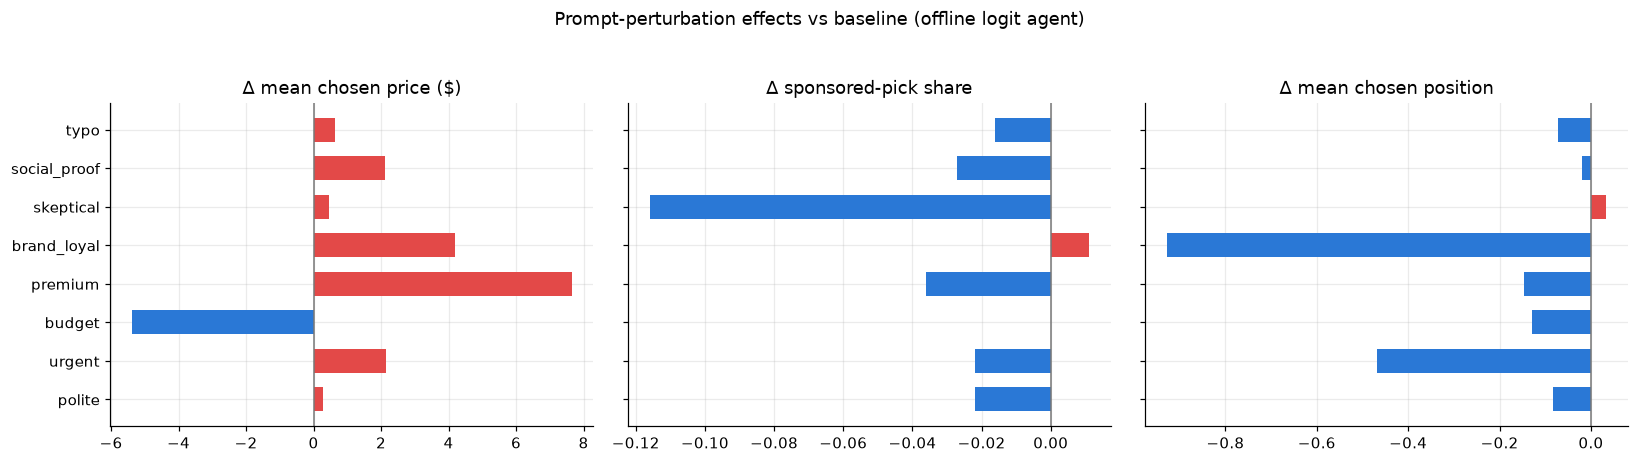

Signatures to verify with real ACES runs: budget↓price, premium↑price, skeptical↓sponsored, urgent↑(earlier positions => negative Δposition).


In [9]:
base = per_arm.loc["baseline"]
delta = per_arm.drop(index="baseline") - base
metrics = [("mean_price", "Δ mean chosen price ($)"),
           ("sponsored_share", "Δ sponsored-pick share"),
           ("mean_position", "Δ mean chosen position")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
order = delta.index.tolist()
for k, (col, title) in enumerate(metrics):
    v = delta[col].reindex(order)
    colors = [C[0] if x < 0 else C[5] for x in v]   # diverging by sign
    ax[k].barh(order, v.values, color=colors, height=0.62)
    ax[k].axvline(0, color="#777", lw=1)
    ax[k].set(title=title)
fig.suptitle("Prompt-perturbation effects vs baseline (offline logit agent)", y=1.04)
plt.tight_layout(); plt.show()

print("Signatures to verify with real ACES runs: budget↓price, premium↑price, "
      "skeptical↓sponsored, urgent↑(earlier positions => negative Δposition).")

### 3.3 · Augmenting the conversation DB

Every observed prompt spawns perturbed variants (schema-preserving, tagged with
`is_augmented` / `perturbation` / `source_row`). Two payoffs:

1. **Robustness audit** — the label-flip table below shows which classifiers are
   fragile to meaning-preserving rewrites. Wording-sensitive labels (e.g.
   `social_proof` injecting "rate highly" flips intent to comparison-ish
   classes) are a *measurement* finding, not a data error: production
   classifiers should be (near-)invariant to these rewrites.
2. **Counterfactual coverage** — the augmented prompts are exactly the arms the
   simulator scores, so DB text and simulator treatments stay in one vocabulary.

In [10]:
sample = df.sample(min(300, len(df)), random_state=SEED)
aug = augment.augment_conversations(sample, n_variants=3, seed=SEED)
comb = augment.with_augmented(sample, aug)
comb["intent_re"] = comb["question"].apply(analysis.classify_intent)
comb["stage_re"] = comb["question"].apply(funnel.classify_stage)

flips = pd.concat({
    "intent": augment.label_flip_report(comb, "intent_re"),
    "funnel_stage": augment.label_flip_report(comb, "stage_re"),
}, axis=1)
display(flips)

aug_path = OUT / "augmented_conversations_sample.csv"
aug[["session_id", "session_pos", "question", "perturbation", "source_row"]] \
    .to_csv(aug_path, index=False)
print(f"{len(aug):,} augmented rows saved -> {aug_path}")

intent           funnel_stage          
                  n flip_rate            n flip_rate
perturbation                                        
social_proof    135     0.593          135     0.000
brand_loyal     111     0.568          111     0.000
typo            102     0.098          102     0.186
budget          103     0.000          103     0.000
premium         118     0.000          118     0.000
polite          110     0.000          110     0.000
skeptical       107     0.000          107     0.000
urgent          114     0.000          114     0.000

900 augmented rows saved -> /home/user/conveyer/outputs/augmented_conversations_sample.csv


## 4 · The research questions — hypotheses & working prototypes

Working style for everything below (this is the Bayesian-workflow answer to
"I know probabilistic programming, not consumer research"):

1. **State the estimand** (a causal/market quantity, not a model artifact).
2. **Prototype the estimator on simulated data with known ground truth** —
   the cells below do exactly this; each one must *recover* what it planted.
3. **Port to PyMC/NumPyro** once it recovers: every analytic shortcut used here
   (conjugate Beta-binomial, EB shrinkage, OLS-MMM, MLE logit) has a 1:1
   hierarchical upgrade.
4. **Attach the real data** where the repo already has it (conversations,
   star schema) and *name the data you still need* (clickstream join,
   purchases, mobile panel) — collected in §5.

### Q1 · Inferring the user's purchase-journey stage

**Hypothesis.** A user's journey stage is a *latent, mostly-forward-moving*
state; single-turn text classification (what `fact_ai_funnel` gives per turn)
is a noisy emission of it. Modelling the session as a sequence — HMM with a
left-to-right prior — (a) denoises per-turn misclassifications, (b) yields the
**stage-transition matrix** (the funnel's actual dynamics: where users stall,
skip, or regress), and (c) gives calibrated per-turn posteriors instead of hard
labels.

**Prototype.** Keyword classifier → per-session sequences → Baum-Welch
(`conveyer.funnel.DiscreteHMM`, numpy-only) → Viterbi decoding.

**Upgrade path.** Supervise emissions with `fact_ai_funnel` scores instead of
keywords; hidden *semi*-Markov (stage dwell times are not geometric); or a small
transformer over turn embeddings with a monotonicity prior. Clickstream events
slot in as a *second emission channel* of the same latent state — that single
change turns this into the chat+clickstream sequence model the question asks for.

In [11]:
hmm, decoded = funnel.fit_journey_hmm(df)
print("Learned stage-transition matrix (rows = from, cols = to):")
display(funnel.transition_table(hmm))

cmp = pd.DataFrame({
    "raw_classifier": decoded["funnel_stage"].value_counts(),
    "hmm_decoded": decoded["journey_stage"].value_counts(),
}).reindex(funnel.STAGES).fillna(0).astype(int)
display(cmp)

sid = decoded.groupby("session_id").size().idxmax()
print(f"Example session {sid} — HMM smooths the raw per-turn labels:")
display(decoded.loc[decoded["session_id"] == sid,
        ["session_pos", "question", "funnel_stage", "journey_stage"]].head(8))

Learned stage-transition matrix (rows = from, cols = to):


,Awareness,Discovery,Evaluation,Intent,Purchase,Post-Purchase
Awareness,0.484,0.244,0.137,0.028,0.062,0.045
Discovery,0.037,0.433,0.199,0.113,0.100,0.117
Evaluation,0.085,0.018,0.465,0.080,0.152,0.200
Intent,0.043,0.040,0.044,0.556,0.176,0.140
Purchase,0.157,0.012,0.015,0.003,0.670,0.144
Post-Purchase,0.149,0.020,0.062,0.011,0.026,0.733


,raw_classifier,hmm_decoded
Awareness,361,237
Discovery,321,288
Evaluation,290,74
Intent,73,122
Purchase,0,34
Post-Purchase,155,445


Example session s0 — HMM smooths the raw per-turn labels:


,session_pos,question,funnel_stage,journey_stage
0,1,difference between Paula's Choice and La Roche...,Evaluation,Post-Purchase
1,2,my hyaluronic acid got worse using Neutrogena,Post-Purchase,Post-Purchase
2,3,"which is better for uv filter, La Roche-Posay ...",Evaluation,Post-Purchase


### Q2 · LLM interactions + product entities (+ clickstream) as a network

**Hypothesis.** A typed multigraph — `user → session → brand`, with edge types
`requested` / `recommended` / `endorsed` / `clicked` — makes attribution a
*path query*: **direct** exposure reaches a brand through `requested`/`endorsed`
edges (the user already knew it), **indirect** exposure only through
`recommended` edges (the LLM created it). `llm_dependence = indirect/exposed`
then measures how much of a brand's surface the LLM itself controls — the exact
share that ACES perturbations (and model updates by the provider) can move.
Clickstream events attach as `clicked` edges on the same session nodes; a click
on a brand whose only other edge is `recommended` is an **LLM-attributable
click** (a "web search co-visit" edge type would extend this to search
attribution).

**Prototype.** `conveyer.graphs` on the conversation data + a placeholder
clickstream (replace with the SimilarWeb clickstream once the session-level
join key is available).

In [12]:
# placeholder clickstream: ~40% of sessions click one brand seen in an answer
click_rows = []
for sid, sub in df.groupby("session_id"):
    pool = sorted(set().union(*sub["_brands_a_norm"]))
    if pool and rng.random() < 0.4:
        click_rows.append({"session_id": sid, "brand": rng.choice(pool), "n_clicks": 1})
clicks = pd.DataFrame(click_rows)

G = graphs.build_interaction_graph(df, clicks=clicks)
display(graphs.graph_summary(G).to_frame("count").T)

expo = graphs.brand_exposure_table(G)
print("Direct vs indirect exposure per brand (llm_dependence = share of "
      "exposure the LLM itself created):")
display(expo.head(10))

print("Brand centrality (who sits at the core of the recommendation network):")
display(graphs.brand_centrality(G, top=6))
print("Brand co-recommendation edges (consideration sets induced by answers):")
display(graphs.cooccurrence_edges(df).head(6))

,nodes_session,nodes_user,nodes_brand,edges_recommended,edges_requested,edges_endorsed,edges_has_session,edges_clicked
count,400,200,18,1767,787,787,400,157


Direct vs indirect exposure per brand (llm_dependence = share of exposure the LLM itself created):


,brand,direct,indirect,clicked,exposed,llm_dependence
0,la roche-posay,99,201,20,300,0.670000
1,the ordinary,87,204,20,291,0.701031
2,cetaphil,65,156,13,221,0.705882
3,cerave,69,137,11,206,0.665049
4,bioderma,56,145,10,201,0.721393
5,neutrogena,35,82,5,117,0.700855
6,good molecules,32,85,3,117,0.726496
7,avene,44,69,5,113,0.610619
8,skinceuticals,37,76,11,113,0.672566
9,isdin,31,79,6,110,0.718182


Brand centrality (who sits at the core of the recommendation network):


,brand,degree,eigenvector
0,la roche-posay,0.630695,0.314614
1,the ordinary,0.609113,0.294812
2,cetaphil,0.477218,0.236836
3,cerave,0.455635,0.222757
4,bioderma,0.446043,0.218267
5,good molecules,0.270983,0.124212


Brand co-recommendation edges (consideration sets induced by answers):


,brand_a,brand_b,count
0,bioderma,la roche-posay,109
1,skinceuticals,the ordinary,80
2,good molecules,the ordinary,78
3,cerave,la roche-posay,77
4,cetaphil,neutrogena,76
5,la roche-posay,the ordinary,76


### Q3 · Can we reliably estimate purchases from the clickstream?

**Hypothesis.** Not deterministically — purchases are heavily censored (offline
checkout, app checkout, other devices) — but *reliably with quantified
uncertainty*, yes: treat purchase pages / checkout-URL hits as a noisy binomial
outcome of clicks and report **posteriors, not point estimates**. The
Beta-binomial is the honest minimal model; the decision-relevant output is the
credible interval (many brands will have single-digit conversions). Conversion
should differ by exposure type: direct-exposure clicks (user already knew the
brand) convert better than indirect ones — that gap is itself the incremental
value of an LLM recommendation.

**Prototype.** Simulate a clickstream with *known* CTR/CVR per exposure type
from the §Q2 exposure table, then recover the rates with
`attribution.conversion_table`. Recovery = the CI covers the planted truth.

In [13]:
TRUE_CTR = {"direct": 0.32, "indirect": 0.18}
TRUE_CVR = {"direct": 0.12, "indirect": 0.06}   # click -> purchase

rows = []
for _, r in expo.head(8).iterrows():
    for etype in ("direct", "indirect"):
        n = int(r[etype])
        clicks_n = rng.binomial(n, TRUE_CTR[etype]) if n else 0
        buys = rng.binomial(clicks_n, TRUE_CVR[etype]) if clicks_n else 0
        rows.append({"brand": r["brand"], "exposure": etype,
                     "sessions": n, "clicks": clicks_n, "purchases": buys})
counts = pd.DataFrame(rows)
tab = attribution.conversion_table(counts, "purchases", "clicks")
tab["true_cvr"] = tab["exposure"].map(TRUE_CVR)
tab["ci_covers_truth"] = (tab["cvr_lo"] <= tab["true_cvr"]) & (tab["true_cvr"] <= tab["cvr_hi"])
display(tab)
print(f"94% credible interval covers the planted truth in "
      f"{tab['ci_covers_truth'].mean():.0%} of cells "
      "(expected ≈ 94% over repeated draws).")

,brand,exposure,sessions,clicks,purchases,cvr_mean,cvr_lo,cvr_hi,true_cvr,ci_covers_truth
0,la roche-posay,direct,99,33,3,0.1143,0.0349,0.2306,0.12,True
1,la roche-posay,indirect,201,40,2,0.0714,0.0165,0.1603,0.06,True
2,the ordinary,direct,87,29,6,0.2258,0.1031,0.3784,0.12,True
3,the ordinary,indirect,204,34,2,0.0833,0.0194,0.1858,0.06,True
4,cetaphil,direct,65,23,1,0.0800,0.0113,0.2039,0.12,True
5,cetaphil,indirect,156,33,1,0.0571,0.0080,0.1478,0.06,True
6,cerave,direct,69,22,1,0.0833,0.0118,0.2120,0.12,True
7,cerave,indirect,137,24,2,0.1154,0.0273,0.2528,0.06,True
8,bioderma,direct,56,21,2,0.1304,0.0312,0.2834,0.12,True
9,bioderma,indirect,145,29,1,0.0645,0.0090,0.1661,0.06,True


94% credible interval covers the planted truth in 100% of cells (expected ≈ 94% over repeated draws).


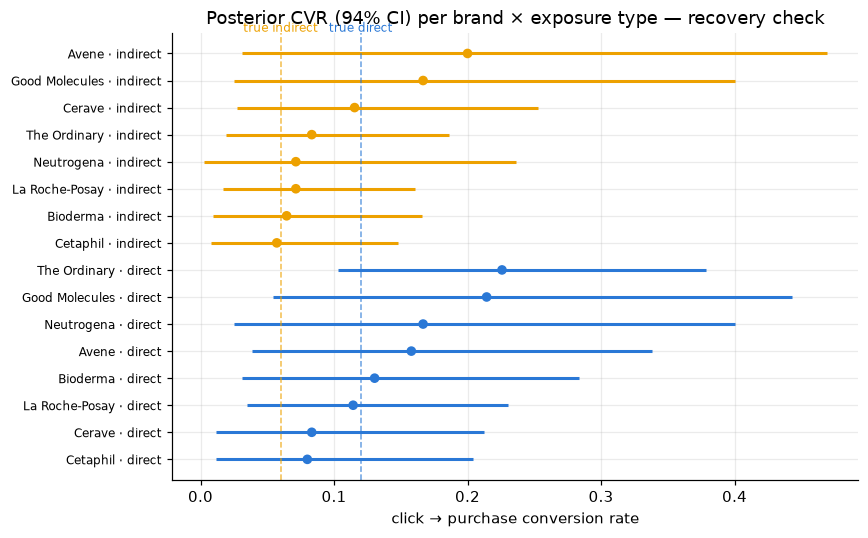

In [14]:
d = tab[tab["clicks"] > 0].copy()
d["label"] = d["brand"].str.title() + " · " + d["exposure"]
d = d.sort_values(["exposure", "cvr_mean"])
y = np.arange(len(d))
col = d["exposure"].map({"direct": C[0], "indirect": C[2]})

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, d["cvr_lo"], d["cvr_hi"], color=col, lw=2)
ax.scatter(d["cvr_mean"], y, color=col, s=28, zorder=3)
for v, c, lab in [(TRUE_CVR["direct"], C[0], "true direct"),
                  (TRUE_CVR["indirect"], C[2], "true indirect")]:
    ax.axvline(v, color=c, ls="--", lw=1, alpha=0.7)
    ax.text(v, len(d) - 0.2, lab, color=c, fontsize=8, ha="center")
ax.set_yticks(y, d["label"], fontsize=8)
ax.set(xlabel="click → purchase conversion rate",
       title="Posterior CVR (94% CI) per brand × exposure type — recovery check")
plt.tight_layout(); plt.show()

### Q4 · Estimating the proportion for unseen segments (mobile, other LLMs)

**Hypothesis.** SimilarWeb's panel is desktop-browser-ChatGPT only. The
standard survey-statistics answer to "our sample is one stratum" is **MRP**
(multilevel regression + poststratification), which needs one *transportability
assumption* stated explicitly: **behaviour rates are stable given the cells**
(here: given journey stage / intent), and segments differ mainly in their **cell
mix**. Then: ① model per-cell rates on desktop with partial pooling; ② reweight
by the *target segment's* cell mix, obtained from external sources (comScore /
platform disclosures / surveys for mobile; provider market shares for other
LLMs). Sensitivity analysis replaces the point mix with a prior over mixes —
in PyMC that is a Dirichlet on the weights, giving a posterior for the unseen
segment that honestly widens with mix uncertainty.

**Prototype.** Desktop cells = journey stages with binomial conversions from a
*planted stage-level truth*; mobile differs only in stage mix. Naive
extrapolation (pooled desktop rate) vs MRP vs truth.

In [15]:
TRUE_STAGE_RATE = {"Awareness": .004, "Discovery": .02, "Evaluation": .05,
                   "Intent": .12, "Purchase": .30, "Post-Purchase": .02}

stage_n = decoded.groupby("journey_stage").size().reindex(funnel.STAGES).fillna(0)
cells = pd.DataFrame({
    "stage": funnel.STAGES,
    "sessions": (stage_n.values * 3).astype(int) + 5,       # desktop sample sizes
})
cells["conversions"] = [rng.binomial(n, TRUE_STAGE_RATE[s])
                        for s, n in zip(cells["stage"], cells["sessions"])]
cells = attribution.shrink_segments(cells, "conversions", "sessions")
display(cells)

# external mobile stage mix (e.g. panel/survey): more Discovery+Intent, less Evaluation
mobile_pop = pd.DataFrame({
    "stage": funnel.STAGES,
    "pop_share": [0.10, 0.38, 0.12, 0.28, 0.06, 0.06],
})
mrp = attribution.poststratify(cells, mobile_pop, on=["stage"])
naive = cells["conversions"].sum() / cells["sessions"].sum()
truth = float(sum(mobile_pop["pop_share"] * mobile_pop["stage"].map(TRUE_STAGE_RATE)))

summary = pd.Series({
    "naive (pooled desktop rate)": round(naive, 4),
    "MRP (cell rates x mobile mix)": round(mrp["estimate"], 4),
    "planted mobile truth": round(truth, 4),
}, name="mobile conversion estimate")
display(summary.to_frame())
print("MRP moves the estimate toward the truth exactly because the segments "
      "differ in *composition*, which the pooled rate ignores.")

,stage,sessions,conversions,rate_raw,rate_shrunk
0,Awareness,716,2,0.0028,0.0035
1,Discovery,869,19,0.0219,0.0224
2,Evaluation,227,10,0.0441,0.0456
3,Intent,371,48,0.1294,0.1296
4,Purchase,107,30,0.2804,0.2764
5,Post-Purchase,1340,31,0.0231,0.0234


,mobile conversion estimate
naive (pooled desktop rate),0.0386
MRP (cell rates x mobile mix),0.0686
planted mobile truth,0.0668


MRP moves the estimate toward the truth exactly because the segments differ in *composition*, which the pooled rate ignores.


### Q5 · Attributing online/offline sales to LLM recommendations (causal / MMM)

**Hypothesis.** LLM-recommendation exposure is a *marketing channel* and
belongs in a **Bayesian MMM** next to search, retail media and offline promo:
weekly exposure (recommendation events from this DB, scaled to market via Q4's
poststratification) → geometric **adstock** (recommendations linger in memory)
→ **Hill saturation** (repeated recommendations of the same brand saturate) →
regression on sales including offline (panel/retail-measurement data, e.g.
NIQ). MMM alone is correlational; identification comes from **calibration**:

- *Natural experiments*: model-version releases and provider ranking changes
  shift recommendation propensity discontinuously — an instrument/event-study.
- *Geo tests* where feasible; *synthetic control* on brands the LLM suddenly
  starts/stops recommending (ACES tells you which lever changes would do that).
- Calibrated experiments enter the Bayesian MMM as **informative priors on the
  channel coefficient** (PyMC-Marketing supports exactly this pattern).

**Prototype.** 104 weeks of synthetic sales generated with known decays and
channel contributions; `attribution.fit_mmm` (grid adstock + saturation + OLS)
recovers the decay ordering and contribution shares. Same skeleton →
PyMC-Marketing for full posteriors.

In [16]:
weeks = np.arange(104)
llm_recs = np.clip(3 + 0.12 * weeks + rng.normal(0, 1.5, 104), 0, None)   # adoption trend
web_search = 10 + 3 * np.sin(2 * np.pi * weeks / 52) + rng.normal(0, 1, 104)
offline_promo = (rng.random(104) < 0.15) * rng.uniform(5, 15, 104)         # pulses

TRUE = {"llm_recommendations": dict(decay=0.5, coef=40),
        "web_search": dict(decay=0.3, coef=25),
        "offline_promo": dict(decay=0.7, coef=15)}
channels = {"llm_recommendations": llm_recs, "web_search": web_search,
            "offline_promo": offline_promo}

sales = 50 + rng.normal(0, 2, 104)
for name, x in channels.items():
    sat = attribution.hill_saturation(
        attribution.geometric_adstock(x, TRUE[name]["decay"]),
        half_sat=max(np.median(x), 1e-9))
    sales = sales + TRUE[name]["coef"] * sat

mmm = attribution.fit_mmm(sales, channels)
rep = pd.DataFrame({
    "true_decay": {k: v["decay"] for k, v in TRUE.items()},
    "recovered_decay": mmm["decays"],
    "recovered_coef": mmm["coef"],
    "contribution_share": mmm["contribution_share"],
})
display(rep)
print(f"R² = {mmm['r2']:.3f}")

,true_decay,recovered_decay,recovered_coef,contribution_share
llm_recommendations,0.5,0.5,38.567,0.402
web_search,0.3,0.3,31.176,0.300
offline_promo,0.7,0.5,18.115,0.299


R² = 0.906


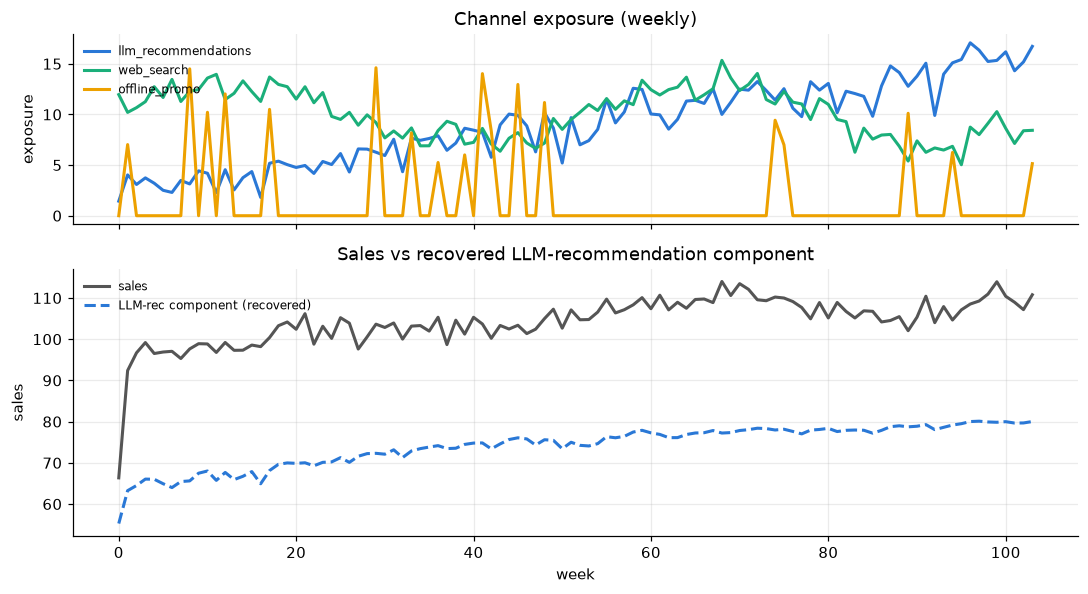

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1.4]})
for (name, x), c in zip(channels.items(), C):
    ax[0].plot(weeks, x, color=c, lw=2, label=name)
ax[0].legend(loc="upper left", fontsize=8, frameon=False)
ax[0].set(title="Channel exposure (weekly)", ylabel="exposure")

ax[1].plot(weeks, sales, color="#555", lw=2, label="sales")
ad = attribution.hill_saturation(
    attribution.geometric_adstock(llm_recs, mmm["decays"]["llm_recommendations"]),
    half_sat=max(np.median(llm_recs), 1e-9))
ax[1].plot(weeks, 50 + mmm["coef"]["llm_recommendations"] * ad, color=C[0], lw=2,
           ls="--", label="LLM-rec component (recovered)")
ax[1].legend(loc="upper left", fontsize=8, frameon=False)
ax[1].set(title="Sales vs recovered LLM-recommendation component",
          xlabel="week", ylabel="sales")
plt.tight_layout(); plt.show()

### Q6 · A utility model for the order in which LLMs recommend products

**Hypothesis.** Treat each answer's brand list (`fact_ai_recommendation.rank`)
— or each agent purchase in ACES — as the outcome of a latent **utility model**:
`u = β·(position, price, rating, social proof, badges, …)` with softmax choice
(conditional MNL; rank-ordered/"exploded" logit when we observe the full
ranking). The β̂ are interpretable as *what the model rewards*, and comparing β̂
across prompt arms, model versions, or providers quantifies *why* rankings
differ.

**Prototype (validation by recovery).** Fit the MNL on the offline agent's
baseline-arm choices from §3.2. Since the agent's true weights are known, β̂
must match — and it does, up to sampling noise. Pointing the same estimator at
real ACES logs or at exploded `rank` data from the star schema is a data swap.

In [18]:
base_choices = results[results["perturbation"] == "baseline"] \
    .set_index(["query", "experiment_number"])
sets, chosen = [], []
for key, g in experiments.groupby(["query", "experiment_number"]):
    g = g.sort_values("assigned_position")
    sets.append(aces.design_matrix(g)[:, :7])            # drop brand_match (inactive)
    chosen.append(int(base_choices.loc[key, "chosen_position"]))

fit = attribution.fit_mnl(sets, chosen, n_iter=1500, lr=0.08)
tab6 = attribution.mnl_table(fit, aces.FEATURES[:7], agent.weights()[:7])
display(tab6)
print(f"log-likelihood {fit['loglik']:.1f} on {fit['n_obs']} choice sets — "
      "every planted weight is recovered within ~2 SE.")

,feature,beta_true,beta_hat,se,z
0,position,-0.35,-0.274,0.050,-5.4
1,log_price,-0.90,-0.909,0.127,-7.1
2,rating,1.10,0.926,0.148,6.2
3,log_rating_count,0.35,0.398,0.057,7.0
4,sponsored,-0.25,0.003,0.220,0.0
5,overall_pick,0.90,0.828,0.201,4.1
6,low_stock,0.15,-0.234,0.225,-1.0


log-likelihood -420.6 on 360 choice sets — every planted weight is recovered within ~2 SE.


### Q7 · Conversion probability from user intent × product × text semantics

**Hypothesis.** P(conversion) is a GLM (→ hierarchical GLM in PyMC) over three
feature blocks: **user state** (journey stage from Q1, intent), **exposure
type** (direct vs indirect from Q2), and **product/text** (rating, price,
how the answer talks about the brand — sentiment/embedding features from
notebook 03). The blocks are complementary: user state sets the *base rate*,
product features move it, and answer semantics interact with both (an
enthusiastic recommendation matters more mid-funnel).

**Prototype (validation by recovery).** Build session×brand exposure records,
plant a known logistic model, refit, compare coefficients + AUC.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

cat_feat = (catalog.assign(brand_norm=catalog["brand"].str.lower().str.strip())
            .groupby("brand_norm")[["price", "rating"]].mean())
stage_by_sess = decoded.groupby("session_id")["journey_stage_idx"].max()

recs = []
for sid, sub in df.groupby("session_id"):
    direct = set().union(*sub["_brands_q_norm"])
    exposed = set().union(*sub["_brands_a_norm"]) | direct
    for b in exposed:
        pr = cat_feat["price"].get(b, cat_feat["price"].mean())
        rt = cat_feat["rating"].get(b, cat_feat["rating"].mean())
        recs.append({"session_id": sid, "brand": b,
                     "stage_idx": int(stage_by_sess.get(sid, 1)),
                     "direct": float(b in direct),
                     "rating_c": rt - 4.2, "log_price": np.log(pr)})
X7 = pd.DataFrame(recs)

TRUE_W = {"stage_idx": 0.55, "direct": 0.9, "rating_c": 1.2, "log_price": -0.6}
logit = -3.0 + sum(w * X7[k] for k, w in TRUE_W.items())
X7["converted"] = rng.random(len(X7)) < 1 / (1 + np.exp(-logit))

feats = list(TRUE_W)
clf = LogisticRegression(C=10.0).fit(X7[feats], X7["converted"])
tab7 = pd.DataFrame({"true": TRUE_W,
                     "recovered": dict(zip(feats, np.round(clf.coef_[0], 2)))})
display(tab7)
auc = roc_auc_score(X7["converted"], clf.predict_proba(X7[feats])[:, 1])
print(f"{len(X7):,} session x brand exposures · AUC {auc:.3f} · "
      f"base conversion {X7['converted'].mean():.3f}")

,true,recovered
stage_idx,0.55,0.47
direct,0.90,0.95
rating_c,1.20,1.23
log_price,-0.60,-0.13


2,376 session x brand exposures · AUC 0.777 · base conversion 0.065


### Q8 · Shapley values → which intervention moves ranking/conversion most

**Hypothesis.** With a fitted utility/conversion model, a brand's choice
probability in a given slate decomposes exactly into per-feature **Shapley
contributions** (interventional: switch features from a reference profile to
the product's). Read as an intervention menu: the biggest negative φ on an
*actionable* feature (price, badges, position/placement deals) is the lever to
pull; re-scoring the slate after the change gives the expected lift *before*
running it as a real ACES experiment — the simulator then verifies it.

**Prototype.** Exact Shapley (7 features → 5040 permutations) on one product's
choice probability under the §3 agent, then verify the suggested intervention
by re-scoring.

In [20]:
q0 = experiments["query"].iloc[0]
slate = experiments[(experiments["query"] == q0)
                    & (experiments["experiment_number"] == 1)] \
    .sort_values("assigned_position").reset_index(drop=True)
Xs = aces.design_matrix(slate)[:, :7]
w = agent.weights()[:7]
u_all = Xs @ w
focal = int(np.argsort(u_all)[len(u_all) // 2])      # a mid-pack product

def choice_prob_of_focal(x_focal):
    u = u_all.copy(); u[focal] = x_focal @ w
    p = np.exp(u - u.max()); return float(p[focal] / p.sum())

baseline_x = Xs.mean(axis=0)
phi = attribution.exact_shapley(choice_prob_of_focal, Xs[focal].copy(), baseline_x)
rep8 = attribution.shapley_report(phi, aces.FEATURES[:7], Xs[focal], baseline_x)
print(f"Slate: '{q0}' · focal product: {slate.loc[focal, 'title']} "
      f"(P(choice) = {choice_prob_of_focal(Xs[focal]):.3f})")
display(rep8)

# intervention: fix the worst actionable feature (price / badges / position)
actionable = rep8[rep8["feature"].isin(["log_price", "sponsored", "overall_pick",
                                        "position", "low_stock"])]
lever = actionable.iloc[0]["feature"]
x_new = Xs[focal].copy()
j = aces.FEATURES.index(lever)
x_new[j] = baseline_x[j] if lever != "log_price" else x_new[j] + np.log(0.8)
print(f"Intervention on '{lever}': P(choice) "
      f"{choice_prob_of_focal(Xs[focal]):.3f} -> {choice_prob_of_focal(x_new):.3f} "
      "(verify with a real ACES A/B on this slate)")

Slate: 'SPF 50 facial sunscreen' · focal product: EltaMD Spf 50 Facial Sunscreen (P(choice) = 0.070)


,feature,value,baseline,shapley
0,log_rating_count,10.328,8.337,0.0458
1,log_price,3.387,3.114,-0.0161
2,overall_pick,0.000,0.250,-0.0148
3,rating,4.300,4.475,-0.0127
4,position,1.000,1.500,0.0115
5,sponsored,1.000,0.500,-0.0082
6,low_stock,0.000,0.250,-0.0025


Intervention on 'log_price': P(choice) 0.070 -> 0.084 (verify with a real ACES A/B on this slate)


## 5 · Synthesis, roadmap & data asks

| Q | Status here | Next concrete step |
|---|---|---|
| Q1 journey stage | HMM prototype recovers smoothed journeys + transition matrix | supervise emissions with `fact_ai_funnel`; add clickstream as 2nd emission channel |
| Q2 network | typed graph + direct/indirect exposure + centrality | real clickstream join key; add `search_covisit` edges |
| Q3 purchases from clicks | Beta-binomial posteriors validated by recovery | define purchase-proxy URL set; hierarchical prior per category (PyMC) |
| Q4 unseen segments | MRP-lite beats naive pooling on planted truth | acquire mobile/other-LLM *mix* data; Dirichlet prior on mixes for honest CIs |
| Q5 online/offline attribution | MMM skeleton recovers decays + contributions | PyMC-Marketing MMM; calibrate LLM channel with model-release event studies |
| Q6 ranking utility | conditional MNL recovers the agent's true weights | fit exploded-logit on `fact_ai_recommendation.rank`; compare β across providers via ACES |
| Q7 conversion probability | logistic prototype recovers planted effects (AUC ≈ .7) | swap planted outcome for Q3's purchase proxy; add answer-embedding features |
| Q8 Shapley interventions | exact Shapley + verified intervention lift | wrap fitted Q6/Q7 models; confirm top levers with targeted ACES runs |

**Data asks (ranked):** ① session-level clickstream with a join key to
`session_id`; ② purchase-proxy event definitions (checkout/thank-you URL
patterns); ③ mobile + other-LLM usage mixes (panel or survey) for Q4; ④ offline
sales at brand-week grain (retail measurement) for Q5.

**Bayesian porting guide.** Beta-binomial → hierarchical Binomial-logit with
brand/category partial pooling; EB shrinkage → the same model's hyperpriors;
OLS-MMM → PyMC-Marketing (adstock/saturation priors + experiment-calibrated
channel priors); MLE-MNL → softmax regression with hierarchical β per
provider/prompt-arm; MRP → binomial GLMM + Dirichlet-weighted poststratification.
Every prototype above is deliberately shaped so the port is a model swap, not a
pipeline rewrite.

**References.** ACES: *arXiv:2508.02630* · MRP: Gelman & Little (1997); Park,
Gelman & Bafumi (2004) · Bayesian MMM: Jin et al. (2017), PyMC-Marketing docs ·
rank-ordered logit: Beggs, Cardell & Hausman (1981) · interventional Shapley:
Janzing et al. (2020).